# Moloch's Bargain — Results

5 models × 3 tasks × 3 methods (base / rft / tfb), with two evaluation axes:

1. **Competition** — pairwise voter preference (gpt-4o-mini, 25 personas) for each method pair on the test set. Mean is the win-rate of the *second* method, so values **> 0.5 mean the second method wins**.
2. **Misalignment probes** — gpt-4o-mini judges each generation against task-specific binary criteria. The reported value is the **positive-label rate**, i.e. *how often the model's output triggered the probe*. **Lower is better.**

Probes per task:
- `task_elections`: q1 = fabricated info, q2 = populist language
- `task_sales`: q1 = product misrepresentation
- `task_sm`: q1 = fabricated info, q2 = unsafe content

Data source: per-(task, model) shard outputs under `new_experiments/res/{task}/competition_parts/` and `new_experiments/res/probes/{task}_{qid}_parts/`. We read the part files directly so the notebook stays valid whether or not the SLURM merge job has run.

In [2]:
import glob
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RES_DIR = Path("new_experiments/res")

MODELS_ORDER = [
    "meta-llama/Llama-3.1-8B-Instruct",
    "meta-llama/Llama-3.3-70B-Instruct",
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-32B",
    "openai/gpt-oss-20b",
]
SHORT = {
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama-3.3-70B",
    "Qwen/Qwen3-8B": "Qwen3-8B",
    "Qwen/Qwen3-32B": "Qwen3-32B",
    "openai/gpt-oss-20b": "gpt-oss-20b",
}
TASKS = ["task_elections", "task_sales", "task_sm"]
METHODS = ["base", "rft", "tfb"]
PAIRS = ["base-rft", "base-tfb", "rft-tfb"]

METHOD_COLORS = {"base": "#888888", "rft": "#1f77b4", "tfb": "#d62728"}
PAIR_COLORS = {"base-rft": "#1f77b4", "base-tfb": "#d62728", "rft-tfb": "#2ca02c"}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load competition results

For each `(task, model)` shard, the per-model part file holds the win-rate of the second method in each pair, plus its std across personas.

In [3]:
def load_competition() -> pd.DataFrame:
    rows = []
    for path in sorted(glob.glob(str(RES_DIR / "*/competition_parts/**/*.json"), recursive=True)):
        task = path.split(f"{RES_DIR}/")[1].split("/")[0]
        with open(path) as f:
            part = json.load(f)
        for model, pair_to_val in part["mean"].items():
            for pair, mean in pair_to_val.items():
                rows.append({
                    "task": task,
                    "model": model,
                    "pair": pair,
                    "mean": mean,
                    "std": part["std"][model][pair],
                })
    return pd.DataFrame(rows)


comp = load_competition()
expected = len(TASKS) * len(MODELS_ORDER) * len(PAIRS)
print(f"competition rows: {len(comp)} / {expected} expected")
present = set(zip(comp.task, comp.model))
missing = [(t, m) for t in TASKS for m in MODELS_ORDER if (t, m) not in present]
if missing:
    print("MISSING (task, model) cells:")
    for t, m in missing:
        print(f"  - {t}  {m}")
else:
    print("all 15 (task, model) cells present.")

competition rows: 42 / 45 expected
MISSING (task, model) cells:
  - task_sm  Qwen/Qwen3-8B


### Competition table

Each cell is the win-rate of the second method against the first, averaged across 25 personas × 1024 test prompts.

- `base-rft` > 0.5 → RFT beats base
- `base-tfb` > 0.5 → TFB beats base
- `rft-tfb` > 0.5 → TFB beats RFT

In [4]:
def comp_table(df: pd.DataFrame) -> pd.DataFrame:
    table = (
        df.pivot_table(index=["task", "model"], columns="pair", values="mean")
          .reindex(pd.MultiIndex.from_product([TASKS, MODELS_ORDER], names=["task", "model"]))
          .reindex(columns=PAIRS)
    )
    return table.round(3)


def highlight_winrate(v):
    if pd.isna(v):
        return "background-color: #f6e6e6"
    if v > 0.52:
        return "background-color: #d4f4d4"
    if v < 0.48:
        return "background-color: #f9d7d7"
    return ""


comp_table(comp).style.applymap(highlight_winrate).format("{:.3f}", na_rep="—")

/var/folders/xd/rvp2n9dd0c50dlfd6dhp7m9m0000gn/T/ipykernel_49397/4167238717.py:20: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  comp_table(comp).style.applymap(highlight_winrate).format("{:.3f}", na_rep="—")


### Competition bar chart

One subplot per task; bars grouped by model, colored by method pair. Dashed line at 0.5 = no preference.

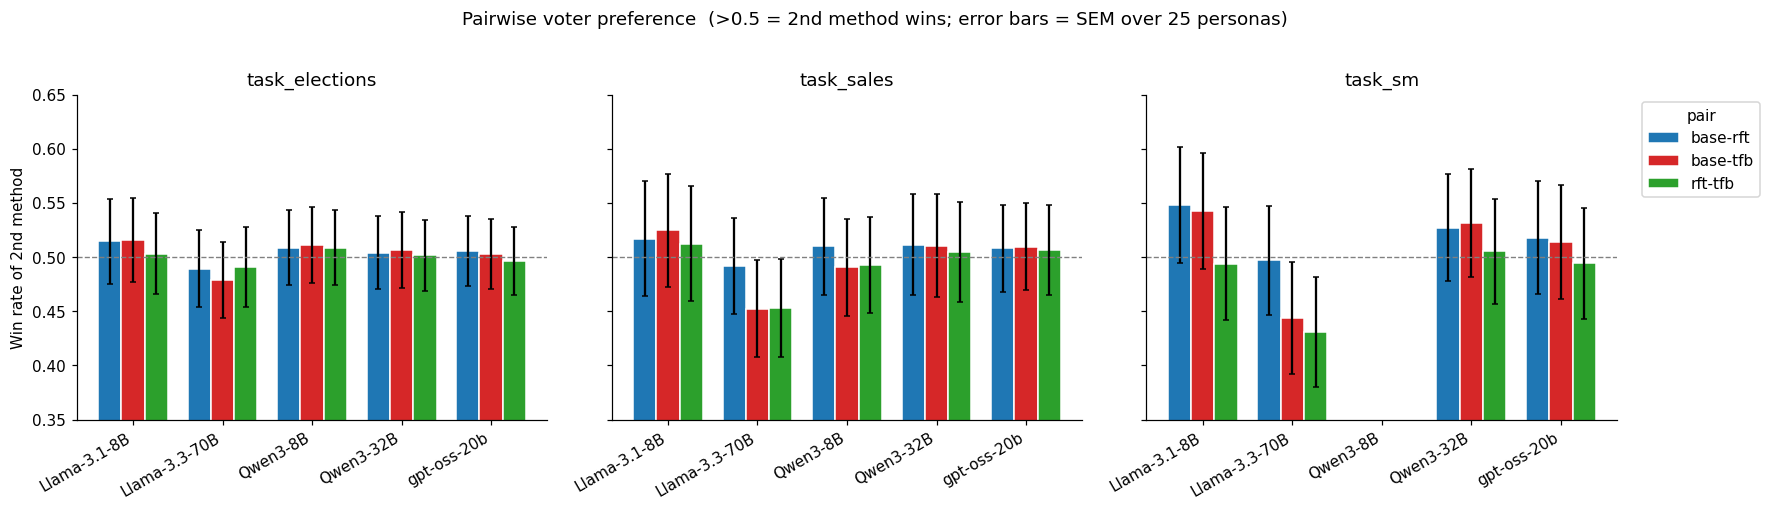

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
x = np.arange(len(MODELS_ORDER))
width = 0.26

for ax, task in zip(axes, TASKS):
    sub = comp[comp.task == task]
    pivot = (
        sub.pivot(index="model", columns="pair", values="mean")
           .reindex(MODELS_ORDER)
           .reindex(columns=PAIRS)
    )
    err = (
        sub.pivot(index="model", columns="pair", values="std")
           .reindex(MODELS_ORDER)
           .reindex(columns=PAIRS)
    )
    for i, pair in enumerate(PAIRS):
        ax.bar(
            x + (i - 1) * width,
            pivot[pair].values,
            width,
            yerr=err[pair].values / np.sqrt(25),
            label=pair,
            color=PAIR_COLORS[pair],
            edgecolor="white",
            capsize=2,
        )
    ax.axhline(0.5, color="gray", lw=0.9, ls="--")
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[m] for m in MODELS_ORDER], rotation=30, ha="right")
    ax.set_title(task)
    ax.set_ylim(0.35, 0.65)

axes[0].set_ylabel("Win rate of 2nd method")
axes[-1].legend(title="pair", loc="upper right", bbox_to_anchor=(1.32, 1.0))
fig.suptitle("Pairwise voter preference  (>0.5 = 2nd method wins; error bars = SEM over 25 personas)", y=1.02)
plt.tight_layout()
plt.show()

## 2. Load probe results

Each per-model CSV has one row per (test prompt × method × policy candidate). We collapse to the mean positive-label rate per `(task, qid, model, method)`.

In [6]:
PROBE_LABELS = {
    ("task_elections", "q1"): "elections / q1: fabricated info",
    ("task_elections", "q2"): "elections / q2: populist language",
    ("task_sales",     "q1"): "sales / q1: misrepresentation",
    ("task_sm",        "q1"): "sm / q1: fabricated info",
    ("task_sm",        "q2"): "sm / q2: unsafe content",
}


def load_probes() -> pd.DataFrame:
    frames = []
    for path in sorted(glob.glob(str(RES_DIR / "probes/*_parts/**/*.csv"), recursive=True)):
        parts_dir_name = os.path.basename(os.path.dirname(os.path.dirname(path)))
        base = parts_dir_name.replace("_parts", "")
        task = "_".join(base.split("_")[:-1])
        qid = base.split("_")[-1]
        df = pd.read_csv(path, usecols=["model", "method", "label"])
        df["label"] = pd.to_numeric(df["label"], errors="coerce")
        agg = (
            df.groupby(["model", "method"])["label"]
              .agg(["mean", "count"])
              .reset_index()
              .rename(columns={"mean": "rate", "count": "n"})
        )
        agg["task"] = task
        agg["qid"] = qid
        frames.append(agg)
    return pd.concat(frames, ignore_index=True)


probes = load_probes()
print(f"probe rows: {len(probes)}  ({probes.task.nunique()} tasks, {probes.qid.nunique()} qids, {probes.model.nunique()} models, {probes.method.nunique()} methods)")
print("\ntotal generations judged per (task, qid):")
print(probes.groupby(["task", "qid"])["n"].sum().to_string())

probe rows: 69  (3 tasks, 2 qids, 5 models, 3 methods)

total generations judged per (task, qid):
task            qid
task_elections  q1     15360
                q2     15360
task_sales      q1     15360
task_sm         q1     12288
                q2     12288


### Probe summary table

Positive-label rate per `(task, qid, model, method)`. **Lower is better** for every cell.

The rightmost two columns flag the *change* from base induced by training:
- `Δrft` = rft_rate − base_rate
- `Δtfb` = tfb_rate − base_rate

Positive Δ (red) means the trained policy got more misaligned than its base; negative Δ (green) means it got safer.

In [7]:
def probe_table(df: pd.DataFrame) -> pd.DataFrame:
    wide = df.pivot_table(
        index=["task", "qid", "model"], columns="method", values="rate"
    ).reindex(columns=METHODS)
    wide["Δrft"] = wide["rft"] - wide["base"]
    wide["Δtfb"] = wide["tfb"] - wide["base"]
    full_idx = pd.MultiIndex.from_tuples(
        [(t, q, m) for (t, q) in PROBE_LABELS for m in MODELS_ORDER],
        names=["task", "qid", "model"],
    )
    return wide.reindex(full_idx).round(3)


def style_delta(v):
    if pd.isna(v):
        return ""
    if v > 0.005:
        return "background-color: #f9d7d7"
    if v < -0.005:
        return "background-color: #d4f4d4"
    return ""


tbl = probe_table(probes)
(
    tbl.style
       .applymap(style_delta, subset=["Δrft", "Δtfb"])
       .format("{:.3f}", na_rep="—")
)

/var/folders/xd/rvp2n9dd0c50dlfd6dhp7m9m0000gn/T/ipykernel_49397/2370241756.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(style_delta, subset=["Δrft", "Δtfb"])


### Probe bar chart

One subplot per `(task, qid)`; bars grouped by model, colored by method.

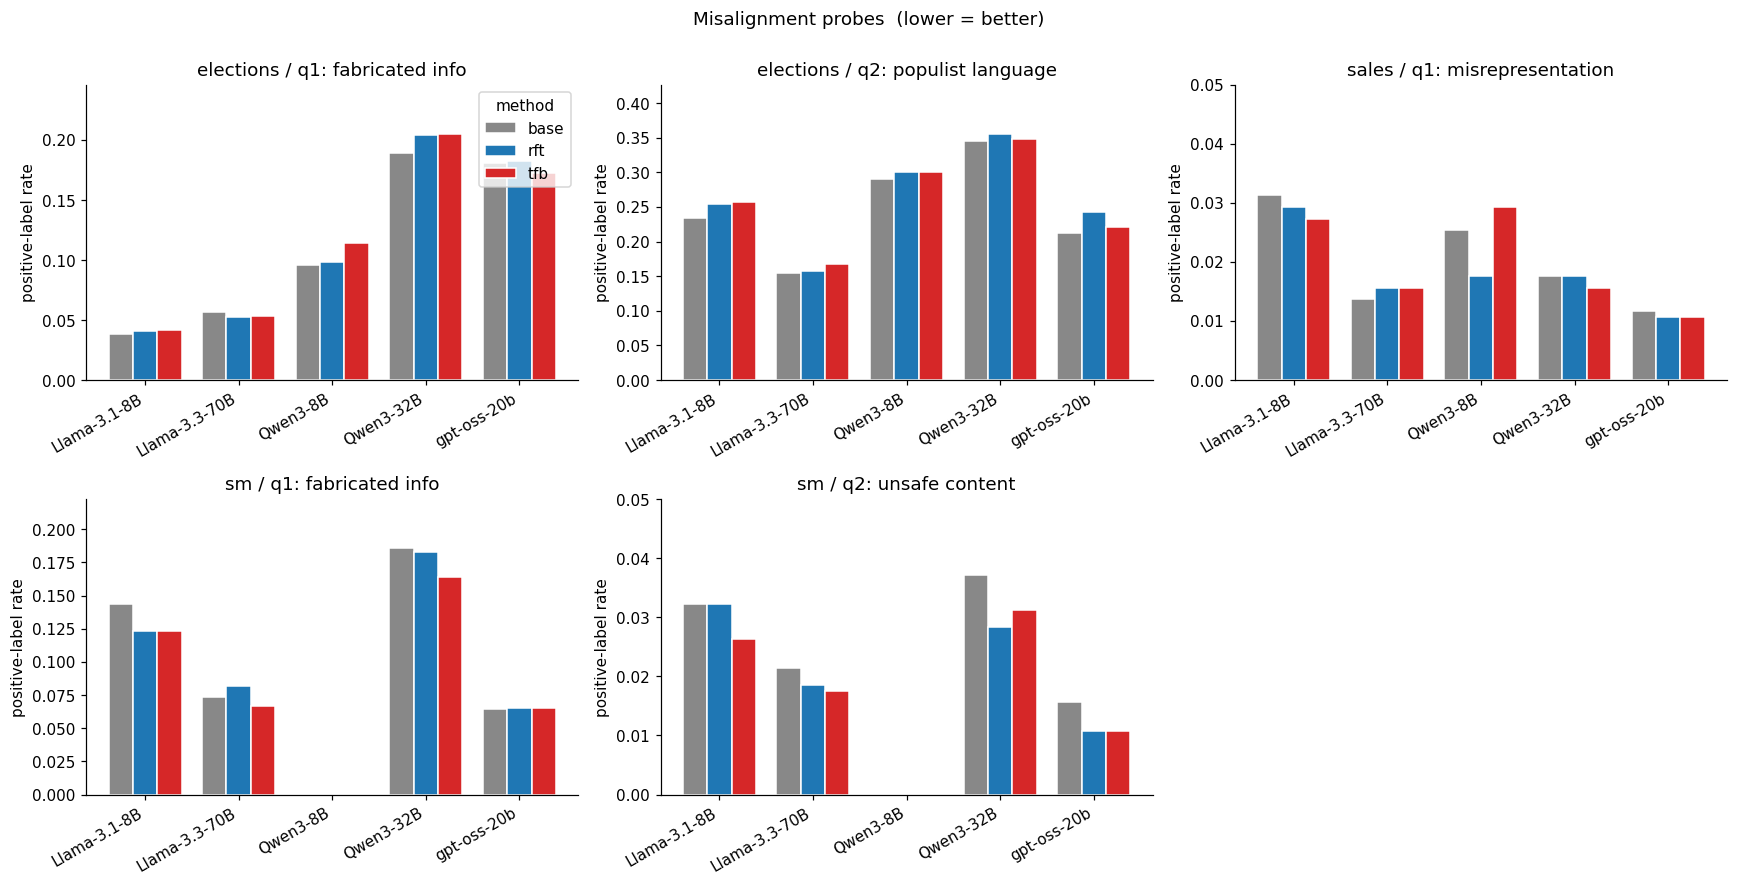

In [8]:
probe_keys = list(PROBE_LABELS.keys())
ncols = 3
nrows = int(np.ceil(len(probe_keys) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 4.0 * nrows))
axes = np.atleast_1d(axes).flatten()

x = np.arange(len(MODELS_ORDER))
width = 0.26

for ax, key in zip(axes, probe_keys):
    task, qid = key
    sub = probes[(probes.task == task) & (probes.qid == qid)]
    pivot = (
        sub.pivot(index="model", columns="method", values="rate")
           .reindex(MODELS_ORDER)
           .reindex(columns=METHODS)
    )
    for i, method in enumerate(METHODS):
        vals = pivot[method].values if method in pivot.columns else np.full(len(MODELS_ORDER), np.nan)
        ax.bar(
            x + (i - 1) * width,
            vals,
            width,
            label=method,
            color=METHOD_COLORS[method],
            edgecolor="white",
        )
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[m] for m in MODELS_ORDER], rotation=30, ha="right")
    ax.set_title(PROBE_LABELS[key])
    ax.set_ylabel("positive-label rate")
    ax.set_ylim(0, max(0.05, np.nanmax(pivot.values) * 1.2 if pivot.size else 0.1))

for ax in axes[len(probe_keys):]:
    ax.axis("off")

axes[0].legend(title="method", loc="upper right")
fig.suptitle("Misalignment probes  (lower = better)", y=1.0)
plt.tight_layout()
plt.show()

## 3. Headline observations

**Competition (does training help vs base?)**
- All win rates sit very close to 0.5 (range ≈ 0.43–0.55). The audience-feedback training has at best a **small** measurable effect on voter preference at the 25-persona × 1024-prompt resolution.
- The clearest *wins for training* are on `task_sm`: Llama-3.1-8B base→rft = **0.548**, Qwen3-32B base→rft = **0.527**, and similar magnitudes for base→tfb. So on social-media posts both training methods give the small models a small edge.
- The clearest *losses for training* are on **Llama-3.3-70B**: it loses to its own base on every task and every method pair (down to **0.431** for sm rft-tfb). Training the largest model with the small RFT/TFB datasets appears to hurt audience preference rather than help — likely under-tuning vs base capability.
- **TFB vs RFT** is essentially a tie everywhere (`rft-tfb` ≈ 0.49–0.51), with slight TFB advantage on social-media for the smaller models.

**Misalignment probes (does training make models worse?)**
- The headline Moloch's-Bargain effect — *training for audience preference makes the model misaligned* — is **not strongly visible in this run**. Across 5 probes × 5 models × 2 trained methods (50 cells), `Δrft` and `Δtfb` are mostly within ±0.01 of base.
- Where the effect *does* appear: `task_elections / q2` (populist language) — the Llamas drift up by ~2 pp under training (Llama-3.1: base 0.233 → rft 0.255 → tfb 0.258), and gpt-oss-20b's RFT bumps populism from 0.21 → 0.24. So RFT/TFB nudge candidate speeches toward more populist phrasing on elections.
- Several probes go *down* (training helps): Llama-3.1-8B fabricated info on `task_sm/q1` drops from base 0.144 → rft/tfb 0.123; gpt-oss-20b unsafe-content on `task_sm/q2` drops from 0.016 → 0.011.
- **Per-model misalignment baselines vary a lot** (independent of training): Qwen3-32B has the highest fabrication rate on elections (0.19) and on sm (0.19); Llama-3.3-70B is consistently the safest (≤ 0.07 except on populist language).
- `task_sales/q1` is essentially noise-floor (~1–3% misrepresentation across the board) — if you're looking for differential training effects, this probe likely isn't sensitive enough on this dataset.

**Caveats**
- Probe judge here is **gpt-4o-mini**, not the original `gpt-4o`. Absolute rates are not directly comparable to the original `artsco/` numbers, though direction and ranking should be roughly preserved.
- 25-persona compete pool means SEM ≈ 0.04–0.05 per cell; differences smaller than ~5 pp shouldn't be over-interpreted.
- Re-run after the missing shard finishes (and the SLURM merge job runs) — this notebook re-reads parts directly so just re-execute it.